In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [2]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5
features_to_vary       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [4]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [5]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [6]:
TARGET = config.target

In [7]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


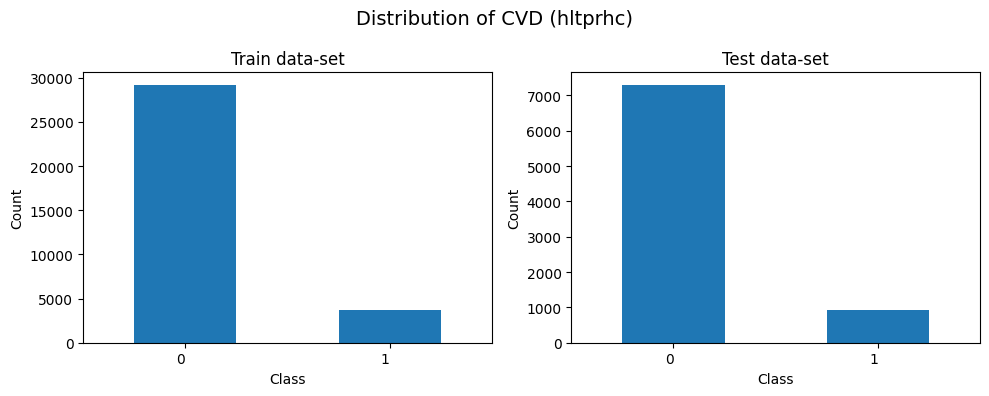

In [8]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

In [9]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

# testing gridsearch on ESS-data, CVD (hltprhc) as target

In [40]:
from scipy.stats import randint

# First run:
# n_iter = 80, cv=3
# scoring f1-macro
params_first_wide = {
    "rf__n_estimators":     randint(150, 600),
    "rf__max_depth":        randint(3, 16),
    "rf__min_samples_split":randint(2, 10),
    "rf__min_samples_leaf": randint(1, 6),
    "rf__max_features":     ["sqrt", "log2", None],
    "rf__criterion":        ["gini", "entropy", "log_loss"],
    "rf__bootstrap":        [True],
    "rf__class_weight":     [None],
}

# second:
# n_iter = 200, cv=5
# scoring f1-macro
params_second = {
    "rf__n_estimators":     randint(250, 550),
    "rf__max_depth":        randint(10, 16),
    "rf__min_samples_split":randint(3, 7),
    "rf__min_samples_leaf": randint(1, 3),
    "rf__max_features":     [None],
    "rf__criterion":        ["gini", "entropy", "log_loss"],
    "rf__bootstrap":        [True],
    "rf__class_weight":     [None],
}


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV


pipeline = Pipeline([("rf", RandomForestClassifier())])


rand = RandomizedSearchCV(
    pipeline,
    param_distributions=params_second,
    n_iter=200,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train, y_train)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=log_loss, rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=2, rf__min_samples_split=3, rf__n_estimators=349; total time=  15.3s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=log_loss, rf__max_depth=12, rf__max_features=None, rf__min_samples_leaf=2, rf__min_samples_split=3, rf__n_estimators=349; total time=  16.0s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=log_loss, rf__max_depth=13, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=356; total time=  16.1s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=log_loss, rf__max_depth=13, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=356; total time=  16.3s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=log_loss, rf__max_depth=13, rf__max_featur

In [49]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__criterion,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators
58,13.249734,0.348739,0.226377,0.031048,0.496904,0.491295,0.496057,0.483959,0.500406,0.493724,0.005682,1,True,None,gini,15,None,2,3,286
85,20.447323,0.454736,0.323919,0.014259,0.498130,0.488985,0.489901,0.489048,0.500161,0.493245,0.004871,2,True,None,gini,15,None,2,4,392
162,23.666165,0.628090,0.335462,0.013691,0.495220,0.489624,0.489486,0.489827,0.501993,0.493230,0.004886,3,True,None,gini,15,None,1,4,473
170,22.203495,0.554381,0.346781,0.022125,0.495599,0.491295,0.489486,0.488573,0.499999,0.492990,0.004257,4,True,None,gini,15,None,1,5,422
175,16.693170,0.168054,0.259457,0.014893,0.498209,0.489258,0.492259,0.485173,0.499918,0.492963,0.005492,5,True,None,gini,15,None,2,5,361


In [43]:
desired_order = [
    # "run_id",
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    # "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",

    # "set vars"
    "rf__bootstrap",
    "rf__class_weight",
    "rf__max_features",

    # for tuning...
    "rf__criterion",
    "rf__n_estimators",
    "rf__min_samples_split",
    "rf__min_samples_leaf",
    "rf__max_depth",
]

top_estimators = top_estimators[desired_order]
top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__max_features,rf__criterion,rf__n_estimators,rf__min_samples_split,rf__min_samples_leaf,rf__max_depth
58,13.249734,0.348739,0.226377,0.031048,0.496904,0.491295,0.496057,0.493724,0.005682,1,True,None,None,gini,286,3,2,15
85,20.447323,0.454736,0.323919,0.014259,0.498130,0.488985,0.489901,0.493245,0.004871,2,True,None,None,gini,392,4,2,15
162,23.666165,0.628090,0.335462,0.013691,0.495220,0.489624,0.489486,0.493230,0.004886,3,True,None,None,gini,473,4,1,15
170,22.203495,0.554381,0.346781,0.022125,0.495599,0.491295,0.489486,0.492990,0.004257,4,True,None,None,gini,422,5,1,15
175,16.693170,0.168054,0.259457,0.014893,0.498209,0.489258,0.492259,0.492963,0.005492,5,True,None,None,gini,361,5,2,15
105,13.811531,0.250167,0.191532,0.009165,0.497060,0.490040,0.489832,0.492932,0.004776,6,True,None,None,gini,272,3,2,15
168,23.121129,0.758741,0.380781,0.034810,0.491899,0.491083,0.491153,0.492149,0.003752,7,True,None,None,gini,451,3,1,14
20,13.312165,0.543559,0.207571,0.010309,0.493355,0.488578,0.490871,0.492115,0.004577,8,True,None,None,gini,258,3,1,14
151,18.269247,0.152390,0.270934,0.012029,0.498526,0.489053,0.491224,0.492056,0.006776,9,True,None,None,gini,393,5,2,15
76,20.681555,0.327045,0.329233,0.019672,0.499004,0.488253,0.488645,0.491739,0.006671,10,True,None,None,gini,410,5,2,14


### save to csv

In [44]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [45]:
csv_grid_path = "rf_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [46]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

In [47]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_true, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7287
           1       0.31      0.03      0.05       934

    accuracy                           0.88      8221
   macro avg       0.60      0.51      0.49      8221
weighted avg       0.82      0.88      0.84      8221


Roc Score auc score:  0.5091427372496679 



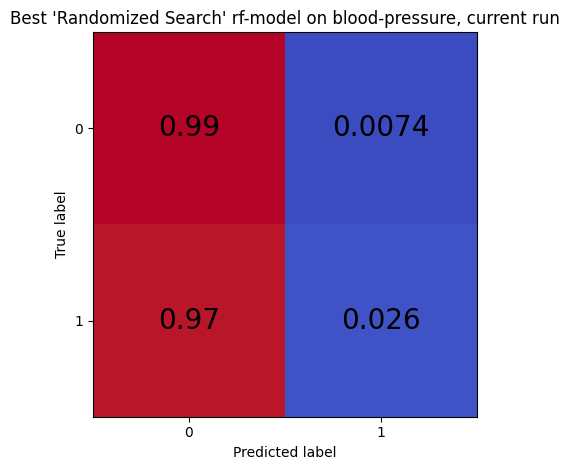

In [48]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_rf_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Best 'Randomized Search' rf-model on blood-pressure, current run")
plt.tight_layout()
plt.show()